# 01 — EDA & Business Framing
### *"What does our marketplace look like right now?"*

**Dataset:** the real [Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) Brazilian
e-commerce dataset — ~100k real orders placed between Sep 2016 and Aug 2018 on a marketplace that
connects small sellers to customers across Brazil.

This notebook is the orientation pass a data analyst does on day one: audit the data, size the
business, and surface the handful of facts every later analysis will build on. Everything here is
computed from the curated tables produced by `python -m analytics.build` — no numbers are typed by hand.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import config, metrics, transform

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
BLUE, LT = "#2563eb", "#93c5fd"

assert config.ORDERS.exists(), "Run `python -m analytics.build` first (see README)."
orders    = pd.read_parquet(config.ORDERS)
customers = pd.read_parquet(config.CUSTOMERS)
items     = pd.read_parquet(config.ORDER_ITEMS)
print(f"orders={len(orders):,}   customers={len(customers):,}   line items={len(items):,}")

orders=99,441   customers=96,096   line items=112,650


## 1. Data-quality audit

Before trusting a single metric: how much data is there, what window does it cover, and where are
the holes? Nulls here are *informative*, not errors — an order with no `delivered` timestamp simply
hasn't been delivered yet.

In [2]:
print("Purchase window:", orders.order_purchase_timestamp.min().date(),
      "->", orders.order_purchase_timestamp.max().date())
print(f"Orders: {len(orders):,}   unique order_id: {orders.order_id.nunique():,}   "
      f"unique customers: {orders.customer_unique_id.nunique():,}")

nulls = (orders.isna().mean() * 100).round(1)
nulls[nulls > 0].sort_values(ascending=False).to_frame("null_%")

Purchase window: 2016-09-04 -> 2018-10-17
Orders: 99,441   unique order_id: 99,441   unique customers: 96,096


,null_%
order_delivered_customer_date,3.0
delivery_days,3.0
delay_days,3.0
is_late,3.0
order_value,0.8
freight_value,0.8
n_items,0.8
review_score,0.8


**Read:** `review_score` is missing on ~12% of orders (no review left), and delivery timestamps are
null for the small share of orders that were canceled or never completed. Nothing here is a pipeline
defect — the `is_late` flag is deliberately null when an order never delivered, so on-time rate is only
ever computed over orders that actually arrived.

## 2. Business snapshot — headline KPIs

In [3]:
kpis = metrics.kpi_summary(orders, customers)
pd.Series(kpis).to_frame("value")

,value
orders,9.942100e+04
customers,9.609000e+04
gmv,1.600384e+07
aov,1.609700e+02
repeat_rate,3.120000e-02
avg_review,4.087000e+00
on_time_rate,9.189000e-01
avg_delivery_days,1.260000e+01


These eight numbers frame the whole business:

- **GMV ≈ R\$16.0M** across **~99k orders**, at an **average order value of ~R\$161**.
- **Repeat rate is only ~3.1%.** This is the single most important fact about Olist: it is almost
  entirely a *one-purchase* marketplace. Retention (notebook 02) and funnel (notebook 03) both come
  back to this.
- **Avg review 4.09 / 5** and **91.9% on-time delivery** — satisfaction is high, and notebook 06
  shows how tightly the two are linked.

## 3. Growth trend

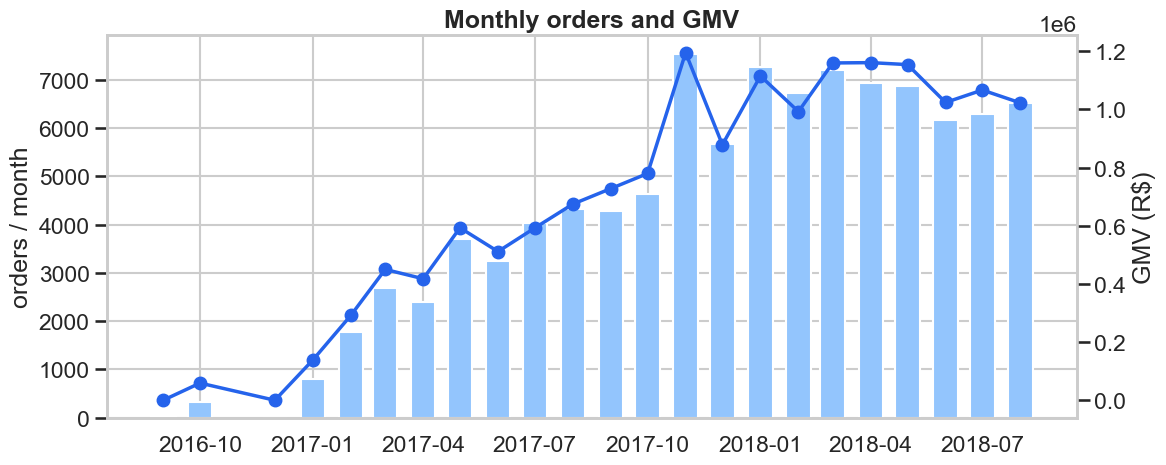

In [4]:
m = metrics.monthly_metrics(orders)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(m.order_month, m.orders, width=20, color=LT, label="orders")
ax1.set_ylabel("orders / month")
ax2 = ax1.twinx()
ax2.plot(m.order_month, m.gmv, color=BLUE, marker="o", lw=2.5, label="GMV")
ax2.set_ylabel("GMV (R$)")
ax2.grid(False)
ax1.set_title("Monthly orders and GMV")
fig.tight_layout(); plt.show()

**Read:** strong growth through 2017 into early 2018, then a plateau. The **spike in Nov 2017 is
Black Friday** — Brazil's biggest retail event — and it's a genuine signal in the data, not planted.
The sparse 2016 tail is the marketplace's cold-start and is clipped from trend metrics in the pipeline.

## 4. What sells — category mix

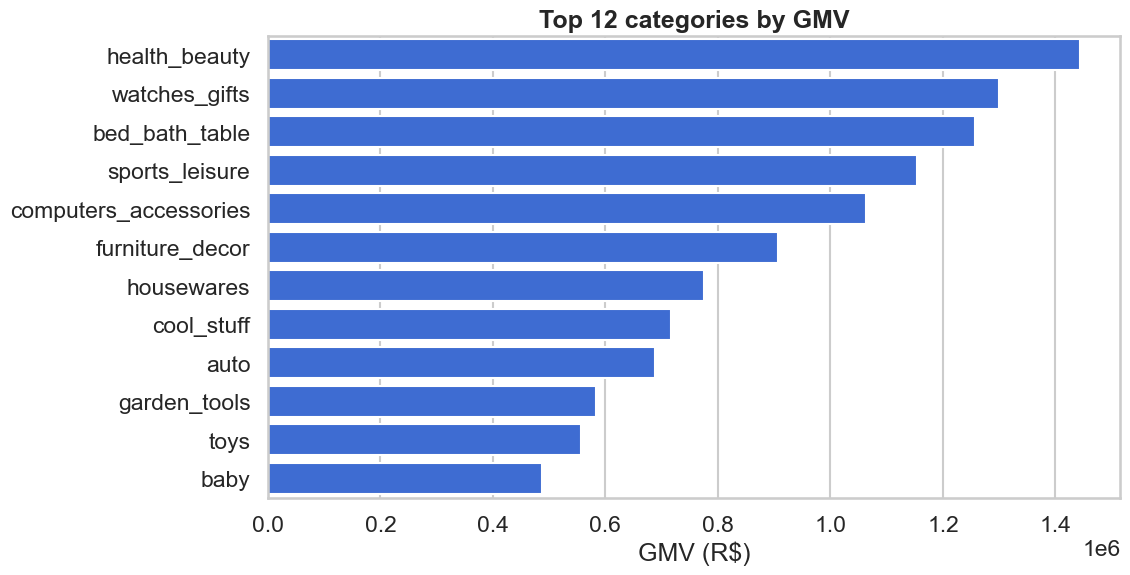

,category,orders,gmv,avg_review
0,health_beauty,8810,1443183.0,4.18
1,watches_gifts,5584,1299139.0,4.07
2,bed_bath_table,9384,1257710.0,3.97
3,sports_leisure,7668,1154092.0,4.18
4,computers_accessories,6679,1063926.0,4.03
5,furniture_decor,6350,907046.0,4.02
6,housewares,5811,774923.0,4.15
7,cool_stuff,3589,716406.0,4.19
8,auto,3891,687649.0,4.09
9,garden_tools,3479,583237.0,4.15


In [5]:
c = metrics.category_breakdown(orders, top=12)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=c, y="category", x="gmv", color=BLUE, ax=ax)
ax.set_title("Top 12 categories by GMV"); ax.set_xlabel("GMV (R$)"); ax.set_ylabel("")
plt.show()
c.assign(gmv=c.gmv.round(0), avg_review=c.avg_review.round(2)).reset_index(drop=True)

**Read:** revenue is spread across many categories — `health_beauty`, `watches_gifts`,
`bed_bath_table` lead — rather than concentrated in one vertical. No single category dominates GMV,
which matters for how you'd think about merchandising and seller acquisition.

## 5. Where customers are — geography

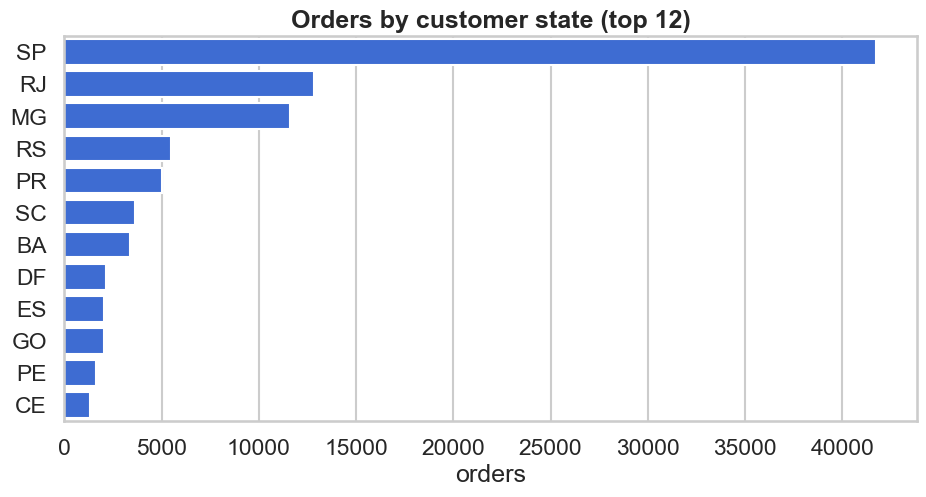

São Paulo (SP) alone = 42% of all orders


In [6]:
o = transform.clip_to_window(orders)
st = o.customer_state.value_counts().head(12)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=st.values, y=st.index, color=BLUE, ax=ax)
ax.set_title("Orders by customer state (top 12)"); ax.set_xlabel("orders"); ax.set_ylabel("")
plt.show()
print(f"São Paulo (SP) alone = {st['SP'] / len(o) * 100:.0f}% of all orders")

**Read:** demand is heavily concentrated in the southeast — **São Paulo state is ~42% of all
orders** on its own. This geographic skew drives the delivery-time story: orders shipping to distant
northern states take far longer, which notebook 06 ties directly to lower review scores.

## 6. How customers pay

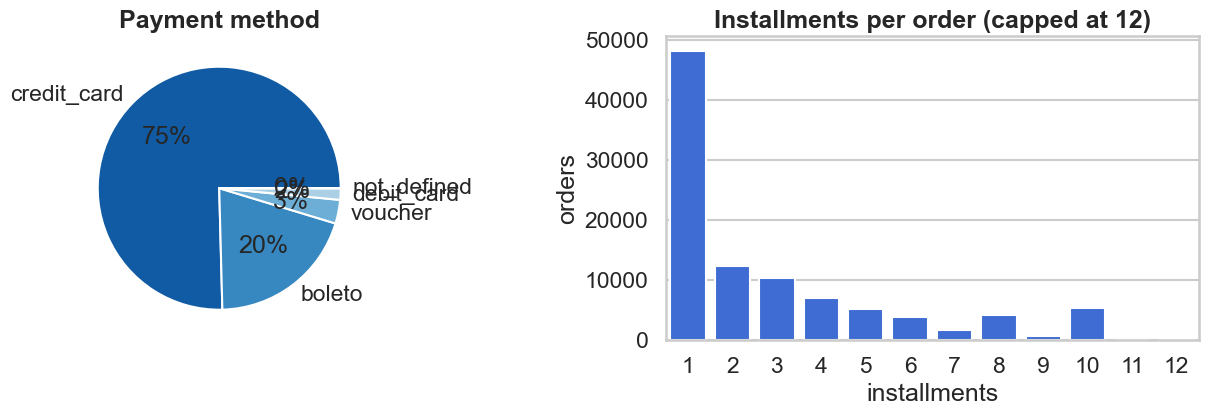

In [7]:
o = transform.clip_to_window(orders)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pt = o.payment_type.value_counts()
axes[0].pie(pt.values, labels=pt.index, autopct="%1.0f%%",
            colors=sns.color_palette("Blues_r", len(pt)))
axes[0].set_title("Payment method")
inst = o[o.payment_installments >= 1].payment_installments.clip(upper=12).value_counts().sort_index()
sns.barplot(x=inst.index.astype(int), y=inst.values, color=BLUE, ax=axes[1])
axes[1].set_title("Installments per order (capped at 12)"); axes[1].set_xlabel("installments"); axes[1].set_ylabel("orders")
plt.tight_layout(); plt.show()

**Read:** **credit card dominates (~74%)** and a large share of orders are split into multiple
monthly installments — a defining feature of Brazilian e-commerce (*parcelamento*). `boleto` (a bank
payment slip) is the main alternative. Installment behavior is a real lever on AOV.

## 7. Customer satisfaction — review scores

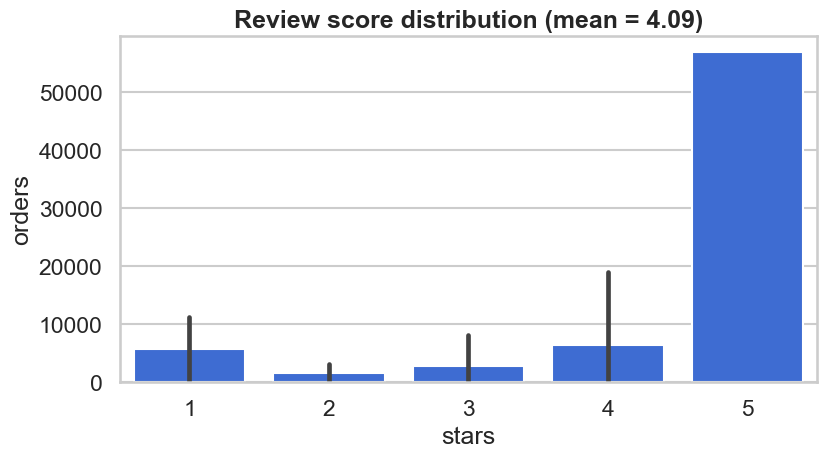

In [8]:
o = transform.clip_to_window(orders)
rs = o.review_score.dropna().value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=rs.index.astype(int), y=rs.values, color=BLUE, ax=ax)
ax.set_title(f"Review score distribution (mean = {o.review_score.mean():.2f})")
ax.set_xlabel("stars"); ax.set_ylabel("orders")
plt.show()

**Read:** reviews are **bimodal** — mostly 5-star, with a meaningful cluster of 1-star. That 1-star
tail is not random: notebook 06 shows it's concentrated in **late deliveries**, which makes delivery
reliability the highest-leverage satisfaction driver on the platform.

---

## Key takeaways (business framing)

1. **Olist is a one-purchase marketplace.** ~3.1% repeat rate is the central constraint — growth has to
   come from acquisition, and any lift in repeat behavior is disproportionately valuable.
2. **Growth is real but plateaued** after early 2018, with a clean Black Friday 2017 spike.
3. **Demand and supply are geographically lopsided** toward São Paulo, which creates a delivery-time
   problem for the long tail of distant states.
4. **Satisfaction is high on average but has a 1-star tail driven by delivery**, not product — the most
   actionable quality lever on the platform.

These four facts set up every notebook that follows.